In [ ]:
# 한글 폰트 설치 + 런타임 재시작
!apt-get install -y fonts-nanum > /dev/null 2>&1
!rm -rf ~/.cache/matplotlib

import os
os.kill(os.getpid(), 9)

In [1]:
# 라이브러리 import & 폰트 설정
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import re, os, time, random, math
import seaborn
import warnings
warnings.filterwarnings('ignore', message='.*findfont.*')

# 한글 폰트 적용
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumBarunGothic')
mpl.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.10.0+cu128


In [2]:
# 데이터 다운로드
!mkdir -p ~/work/transformer/data
!wget -q https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz -P ~/work/transformer/data
!cd ~/work/transformer/data && gzip -d -f korean-english-park.train.tar.gz && tar -xf korean-english-park.train.tar
print("데이터 다운로드 완료")

데이터 다운로드 완료


In [3]:
# 데이터 정제 - 중복 제거 & 전처리 함수
data_dir = os.path.join(os.getenv("HOME"), 'work/transformer/data')
kor_path = data_dir + "/korean-english-park.train.ko"
eng_path = data_dir + "/korean-english-park.train.en"

# set으로 중복 제거 (병렬 쌍 유지)
def clean_corpus(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)
    cleaned_corpus = list(set(["\t".join([k, e]) for k, e in zip(kor, eng)]))
    return cleaned_corpus

# 소문자 변환, 알파벳/한글/문장부호만 남기고, 문장부호 양옆 공백 추가
def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    return sentence.strip()

cleaned_corpus = clean_corpus(kor_path, eng_path)
print(f"중복 제거 후 데이터 수: {len(cleaned_corpus)}")

중복 제거 후 데이터 수: 78968


In [4]:
# SentencePiece 토크나이저 생성
!pip install -q sentencepiece
import sentencepiece as spm

def generate_tokenizer(corpus, vocab_size, lang="ko",
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    file = f"./{lang}_corpus.txt"
    model = f"{lang}_spm"
    with open(file, 'w') as f:
        for row in corpus:
            f.write(str(row) + '\n')
    spm.SentencePieceTrainer.Train(
        f'--input={file} --model_prefix={model} --vocab_size={vocab_size} '
        f'--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}'
    )
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f'{model}.model')
    return tokenizer

SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

# 한영 코퍼스 분리 후 정제
eng_corpus, kor_corpus = [], []
for pair in cleaned_corpus:
    k, e = pair.split("\t")
    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
# 타겟에 BOS/EOS 토큰 자동 추가
en_tokenizer.set_encode_extra_options("bos:eos")

print(f"ko vocab: {ko_tokenizer.get_piece_size()}, en vocab: {en_tokenizer.get_piece_size()}")

ko vocab: 20000, en vocab: 20000


In [5]:
# 학습 데이터 구축 (토큰 길이 50 이하만)
from tqdm import tqdm

src_corpus, tgt_corpus = [], []
for idx in tqdm(range(len(kor_corpus))):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx])
    if len(src_tokens) <= 50 and len(tgt_tokens) <= 50:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

# 패딩 처리
enc_train = torch.nn.utils.rnn.pad_sequence(src_corpus, batch_first=True, padding_value=0)
dec_train = torch.nn.utils.rnn.pad_sequence(tgt_corpus, batch_first=True, padding_value=0)
print(f"enc_train: {enc_train.shape}, dec_train: {dec_train.shape}")

100%|██████████| 78968/78968 [00:09<00:00, 8739.87it/s] 


enc_train: torch.Size([72107, 50]), dec_train: torch.Size([72107, 50])


In [6]:
# Positional Encoding
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])  # 짝수: sin
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])  # 홀수: cos
    return sinusoid_table

print("Positional Encoding 정의 완료")

Positional Encoding 정의 완료


In [7]:
# Multi-Head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = K.size(-1)
        # Q*K^T / sqrt(d_k)
        scaled_qk = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        # 마스크 위치에 큰 음수를 더해 softmax에서 0으로 만듦
        if mask is not None:
            scaled_qk += (mask * -1e9)
        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        # [batch, length, d_model] -> [batch, num_heads, length, depth]
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def combine_heads(self, x):
        # [batch, num_heads, length, depth] -> [batch, length, d_model]
        batch_size = x.size(0)
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(batch_size, -1, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ = self.split_heads(self.W_q(Q))
        WK = self.split_heads(self.W_k(K))
        WV = self.split_heads(self.W_v(V))
        out, attn_weights = self.scaled_dot_product_attention(WQ, WK, WV, mask)
        out = self.linear(self.combine_heads(out))
        return out, attn_weights

print("MultiHeadAttention 정의 완료")

MultiHeadAttention 정의 완료


In [8]:
# Position-wise Feed-Forward Network
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)   # 512 -> 2048
        self.w_2 = nn.Linear(d_ff, d_model)    # 2048 -> 512
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.w_2(self.relu(self.w_1(x)))

print("PoswiseFeedForwardNet 정의 완료")

PoswiseFeedForwardNet 정의 완료


In [9]:
# Encoder Layer (Pre-LN 방식)
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Self-Attention + Residual
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out) + residual

        # FFN + Residual
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out) + residual
        return out, enc_attn

print("EncoderLayer 정의 완료")

EncoderLayer 정의 완료


In [10]:
# Decoder Layer
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        # Masked Self-Attention (미래 토큰 참조 방지)
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, causality_mask)
        out = self.dropout(out) + residual

        # Encoder-Decoder Attention
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, padding_mask)
        out = self.dropout(out) + residual

        # FFN
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out) + residual
        return out, dec_attn, dec_enc_attn

print("DecoderLayer 정의 완료")

DecoderLayer 정의 완료


In [11]:
# Encoder & Decoder 스택
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for layer in self.enc_layers:
            out, enc_attn = layer(out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x
        dec_attns, dec_enc_attns = [], []
        for layer in self.dec_layers:
            out, dec_attn, dec_enc_attn = layer(out, enc_out, causality_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

print("Encoder & Decoder 정의 완료")

Encoder & Decoder 정의 완료


In [12]:
# Transformer 모델
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared=True):
        super(Transformer, self).__init__()
        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional Encoding 미리 계산
        pos_enc = positional_encoding(pos_len, d_model)
        self.pos_encoding = torch.tensor(pos_enc, dtype=torch.float32)

        self.dropout = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        # shared=True: Decoder Embedding과 출력층 Weight 공유
        if shared:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)
        # Weight Tying 시 sqrt(d_model) 곱해줌
        if self.shared:
            out *= math.sqrt(self.d_model)
        # [length, d_model] -> [1, length, d_model]로 브로드캐스팅
        pos = self.pos_encoding[:seq_len, :].unsqueeze(0).to(x.device)
        out = self.dropout(out + pos)
        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_enc_mask):
        # 인자 순서: enc_mask, causality_mask(decoder self), dec_enc_mask(cross)
        enc_emb = self.embedding(self.enc_emb, enc_in)
        dec_emb = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(
            dec_emb, enc_out, causality_mask, dec_enc_mask
        )
        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

print("Transformer 정의 완료")

Transformer 정의 완료


In [13]:
# Masking 함수
def generate_padding_mask(seq):
    """PAD(0) 위치를 1로 표시"""
    return (seq == 0).float().unsqueeze(1).unsqueeze(2)

def generate_causality_mask(size):
    """상삼각 행렬 - 미래 토큰 마스킹"""
    return torch.triu(torch.ones(size, size), diagonal=1)

def generate_masks(src, tgt):
    # 1) Encoder self-attention용: src PAD 마스크
    enc_mask = generate_padding_mask(src)

    # 2) Decoder self-attention용: causal + tgt PAD 결합
    tgt_len = tgt.size(1)
    causal_mask = generate_causality_mask(tgt_len).to(tgt.device)
    tgt_pad_mask = generate_padding_mask(tgt)
    causality_mask = torch.max(tgt_pad_mask, causal_mask.unsqueeze(0).unsqueeze(0))

    # 3) Encoder-Decoder cross attention용: src PAD 마스크
    dec_enc_mask = generate_padding_mask(src)

    return enc_mask, causality_mask, dec_enc_mask

print("Masking 함수 정의 완료")

Masking 함수 정의 완료


In [14]:
# shared=False로 변경 — embedding 스케일링 문제 제거
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared=False   # ← 여기만 변경
).to(device)

optimizer = optim.Adam(
    transformer.parameters(),
    lr=1e-4,
    betas=(0.9, 0.98),
    eps=1e-9
)

class LRScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.step_num = 0

    def step(self, optimizer):
        self.step_num += 1
        lr = (self.d_model ** -0.5) * min(
            self.step_num ** -0.5,
            self.step_num * (self.warmup_steps ** -1.5)
        )
        for p in optimizer.param_groups:
            p['lr'] = lr

scheduler = LRScheduler(d_model=512, warmup_steps=4000)
print("모델 재선언 완료 (shared=False)")

모델 재선언 완료 (shared=False)


In [15]:
# Loss 함수 & Train Step
loss_object = nn.CrossEntropyLoss(reduction='none')

def loss_function(real, pred):
    # pred: [batch, length, vocab] -> [batch, vocab, length]
    loss_ = loss_object(pred.transpose(1, 2), real)
    mask = (real != 0).float()
    loss_ *= mask
    return loss_.sum() / mask.sum()

def train_step(src, tgt, model, optimizer, scheduler):
    model.train()
    tgt_input = tgt[:, :-1]  # 디코더 입력: 마지막 토큰 제거
    gold = tgt[:, 1:]         # 정답: 첫 토큰(BOS) 제거

    # 마스크 생성
    enc_mask, causality_mask, dec_enc_mask = generate_masks(src, tgt_input)

    optimizer.zero_grad()
    # forward 순서: enc_mask, causality_mask, dec_enc_mask
    predictions, _, _, _ = model(
        src, tgt_input, enc_mask, causality_mask, dec_enc_mask
    )
    loss = loss_function(gold, predictions)
    loss.backward()
    optimizer.step()
    scheduler.step(optimizer)  # 매 배치마다 lr 업데이트

    return loss

print("Train Step 정의 완료")

Train Step 정의 완료


In [16]:
# 번역 함수
def evaluate(sentence, model, src_tokenizer, tgt_tokenizer):
    model.eval()
    sentence = preprocess_sentence(sentence)
    pieces = src_tokenizer.encode_as_pieces(sentence)
    tokens = src_tokenizer.encode_as_ids(sentence)
    src = torch.tensor(tokens).unsqueeze(0).to(device)

    ids = []
    output = torch.tensor([[tgt_tokenizer.bos_id()]]).to(device)

    with torch.no_grad():
        for _ in range(50):
            enc_mask, causality_mask, dec_enc_mask = generate_masks(src, output)
            enc_mask = enc_mask.to(device)
            causality_mask = causality_mask.to(device)
            dec_enc_mask = dec_enc_mask.to(device)

            preds, enc_attns, dec_attns, dec_enc_attns = model(
                src, output, enc_mask, causality_mask, dec_enc_mask
            )
            pred_id = preds[0, -1].argmax().item()
            if pred_id == tgt_tokenizer.eos_id():
                break
            ids.append(pred_id)
            output = torch.cat([output, torch.tensor([[pred_id]]).to(device)], dim=-1)

    result = tgt_tokenizer.decode_ids(ids)
    return pieces, result, enc_attns, dec_attns, dec_enc_attns


def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    pieces, result, enc_attns, dec_attns, dec_enc_attns = evaluate(
        sentence, model, src_tokenizer, tgt_tokenizer
    )
    print(f'Input: {sentence}')
    print(f'Predicted: {result}')
    if plot_attention:
        visualize_attention(pieces, result.split(), enc_attns, dec_attns, dec_enc_attns)

print("번역 함수 정의 완료")

번역 함수 정의 완료


In [17]:
# Attention 시각화 함수
font_prop = fm.FontProperties(fname='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf', size=9)

def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns):
    def draw(data, ax, x="auto", y="auto"):
        seaborn.heatmap(data, square=True, vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax, xticklabels=x, yticklabels=y)
        for label in ax.get_xticklabels():
            label.set_fontproperties(font_prop)
        for label in ax.get_yticklabels():
            label.set_fontproperties(font_prop)

    n_layers = len(enc_attns)
    n_heads = min(4, enc_attns[0].size(1))

    for layer in range(n_layers):
        fig, axs = plt.subplots(1, n_heads, figsize=(20, 10))
        print(f"Encoder Layer {layer + 1}")
        for h in range(n_heads):
            draw(enc_attns[layer][0, h, :len(src), :len(src)].cpu().numpy(), axs[h], src, src)
        plt.tight_layout(); plt.show()

    for layer in range(n_layers):
        fig, axs = plt.subplots(1, n_heads, figsize=(20, 10))
        print(f"Decoder Self Layer {layer + 1}")
        for h in range(n_heads):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)].cpu().numpy(), axs[h], tgt, tgt)
        plt.tight_layout(); plt.show()

        fig, axs = plt.subplots(1, n_heads, figsize=(20, 10))
        print(f"Decoder Src Layer {layer + 1}")
        for h in range(n_heads):
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)].cpu().numpy(), axs[h], src, tgt)
        plt.tight_layout(); plt.show()

print("Attention 시각화 함수 정의 완료")

Attention 시각화 함수 정의 완료


In [18]:
# 학습 (10 에폭)
from tqdm import tqdm

BATCH_SIZE = 64
EPOCHS = 10

examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

enc_train_gpu = enc_train.to(device)
dec_train_gpu = dec_train.to(device)

for epoch in range(EPOCHS):
    total_loss = 0
    idx_list = list(range(0, enc_train_gpu.size(0), BATCH_SIZE))
    random.shuffle(idx_list)
    t = tqdm(idx_list)

    for batch, idx in enumerate(t):
        loss = train_step(
            enc_train_gpu[idx:idx+BATCH_SIZE],
            dec_train_gpu[idx:idx+BATCH_SIZE],
            transformer, optimizer, scheduler
        )
        total_loss += loss.item()
        t.set_description(f'Epoch {epoch+1:2d}')
        t.set_postfix({'Loss': f'{total_loss/(batch+1):.4f}'})

    print(f"\n--- Epoch {epoch+1} 번역 결과 ---")
    for ex in examples:
        translate(ex, transformer, ko_tokenizer, en_tokenizer)
    print()

Epoch  1: 100%|██████████| 1127/1127 [03:39<00:00,  5.13it/s, Loss=6.3551]



--- Epoch 1 번역 결과 ---
Input: 오바마는 대통령이다.
Predicted: obama s obama is a obama of obama s obama s president elect .
Input: 시민들은 도시 속에 산다.
Predicted: the dow is a very .
Input: 커피는 필요 없다.
Predicted: the dow is a little .
Input: 일곱 명의 사망자가 발생했다.
Predicted: the two days of the two days of the two days of the two days .



Epoch  2: 100%|██████████| 1127/1127 [03:40<00:00,  5.12it/s, Loss=5.0115]



--- Epoch 2 번역 결과 ---
Input: 오바마는 대통령이다.
Predicted: obama is a great victory .
Input: 시민들은 도시 속에 산다.
Predicted: the city struck a third round .
Input: 커피는 필요 없다.
Predicted: there is no immediately important .
Input: 일곱 명의 사망자가 발생했다.
Predicted: at least people were killed in the death toll in the death .



Epoch  3: 100%|██████████| 1127/1127 [03:38<00:00,  5.15it/s, Loss=4.5235]


...


--- Epoch 8 번역 결과 ---
Input: 오바마는 대통령이다.
Predicted: obama is the president elect .
Input: 시민들은 도시 속에 산다.
Predicted: the city is located in the city .
Input: 커피는 필요 없다.
Predicted: coffee is no need for the need .
Input: 일곱 명의 사망자가 발생했다.
Predicted: the death toll from the quake s .



Epoch  9: 100%|██████████| 1127/1127 [03:38<00:00,  5.16it/s, Loss=3.3162]



--- Epoch 9 번역 결과 ---
Input: 오바마는 대통령이다.
Predicted: obama is the president elect .
Input: 시민들은 도시 속에 산다.
Predicted: the city is a city in the city of urban mountains .
Input: 커피는 필요 없다.
Predicted: coffee is no coffee .
Input: 일곱 명의 사망자가 발생했다.
Predicted: about people were killed tuesday when the blast left the dead tuesday night .



Epoch 10: 100%|██████████| 1127/1127 [03:38<00:00,  5.15it/s, Loss=3.2113]



--- Epoch 10 번역 결과 ---
Input: 오바마는 대통령이다.
Predicted: obama is the president elect .
Input: 시민들은 도시 속에 산다.
Predicted: the city is one of the most popular cities .
Input: 커피는 필요 없다.
Predicted: coffee is no coffee .
Input: 일곱 명의 사망자가 발생했다.
Predicted: sunday s death toll was killed .



최종 번역 결과 + Attention Map
Input: 오바마는 대통령이다.
Predicted: obama is the president elect .
Encoder Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


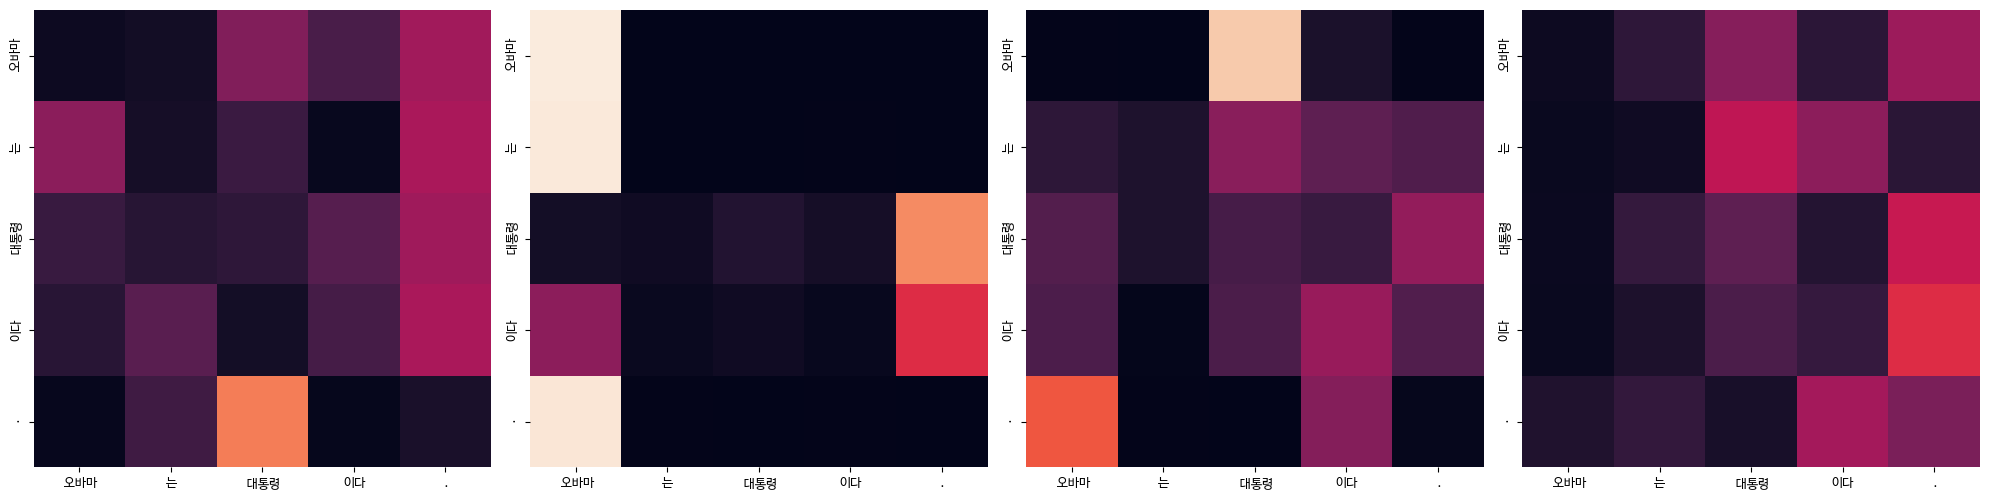

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()


Encoder Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


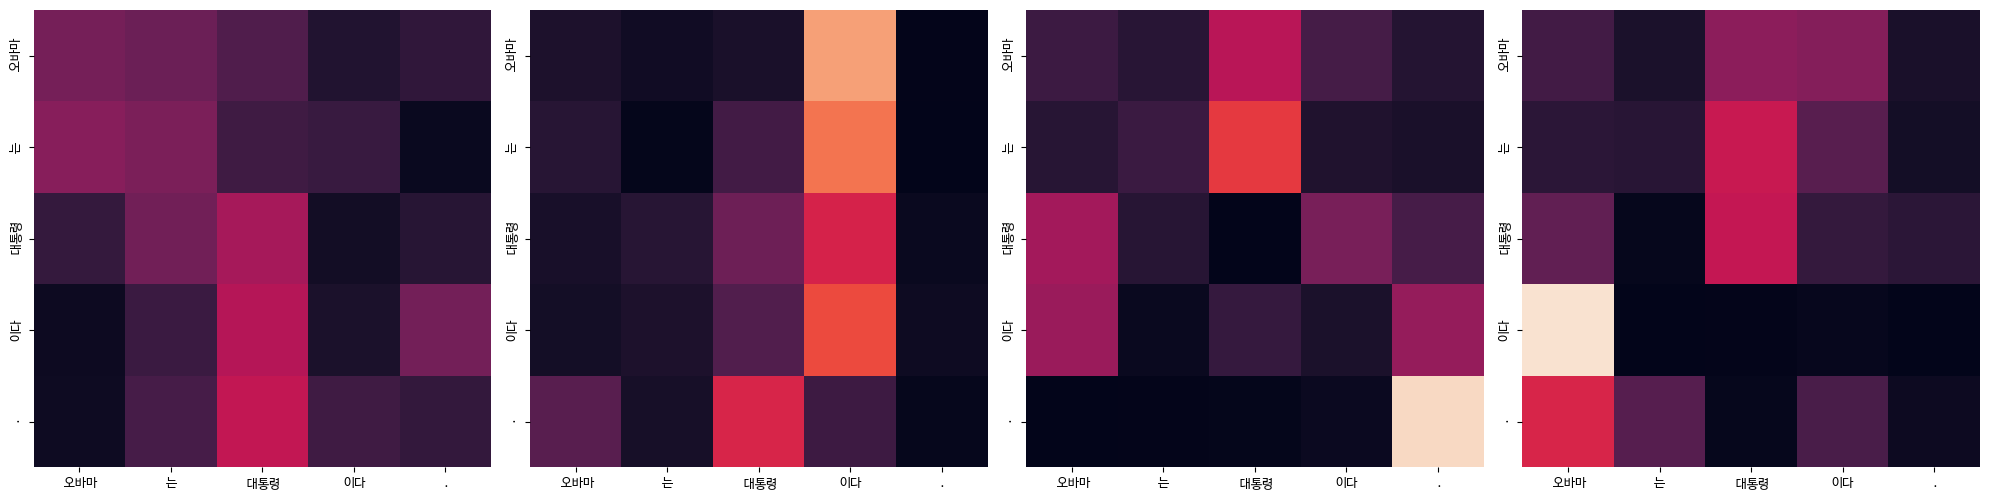

Decoder Self Layer 1


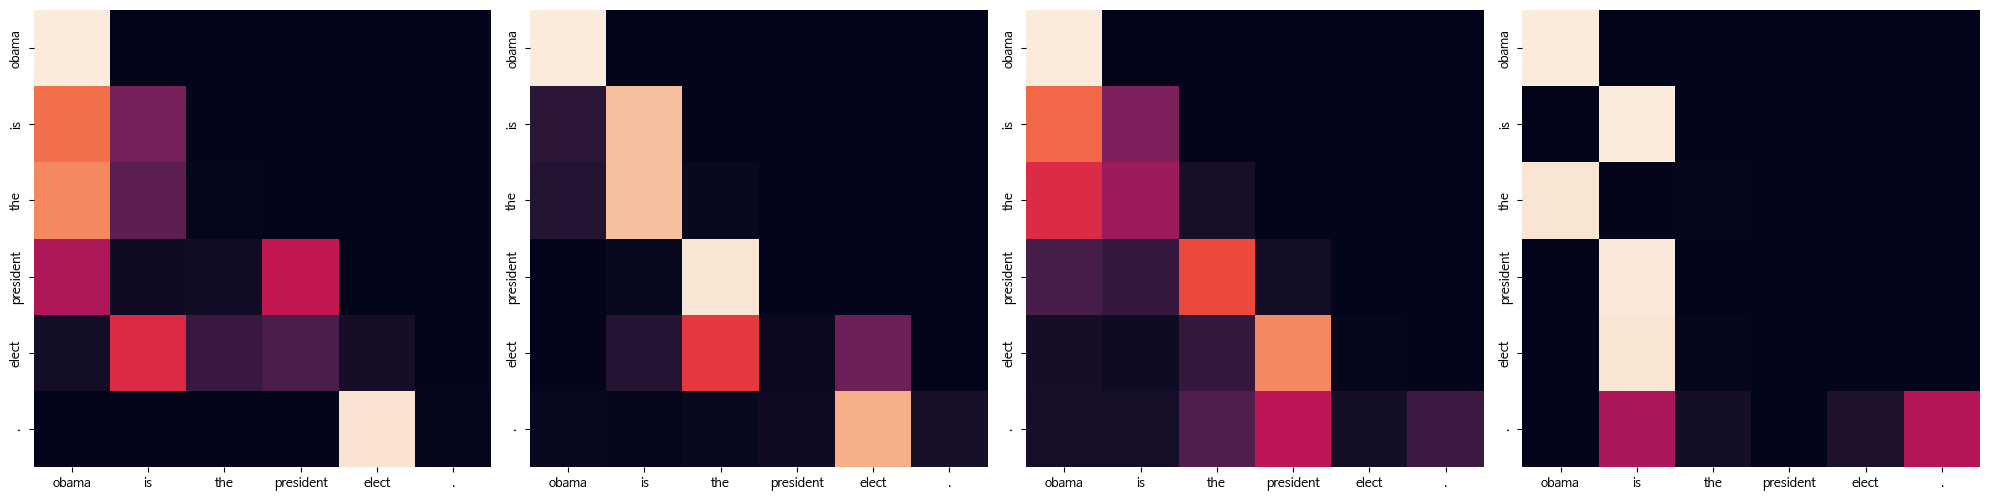

Decoder Src Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


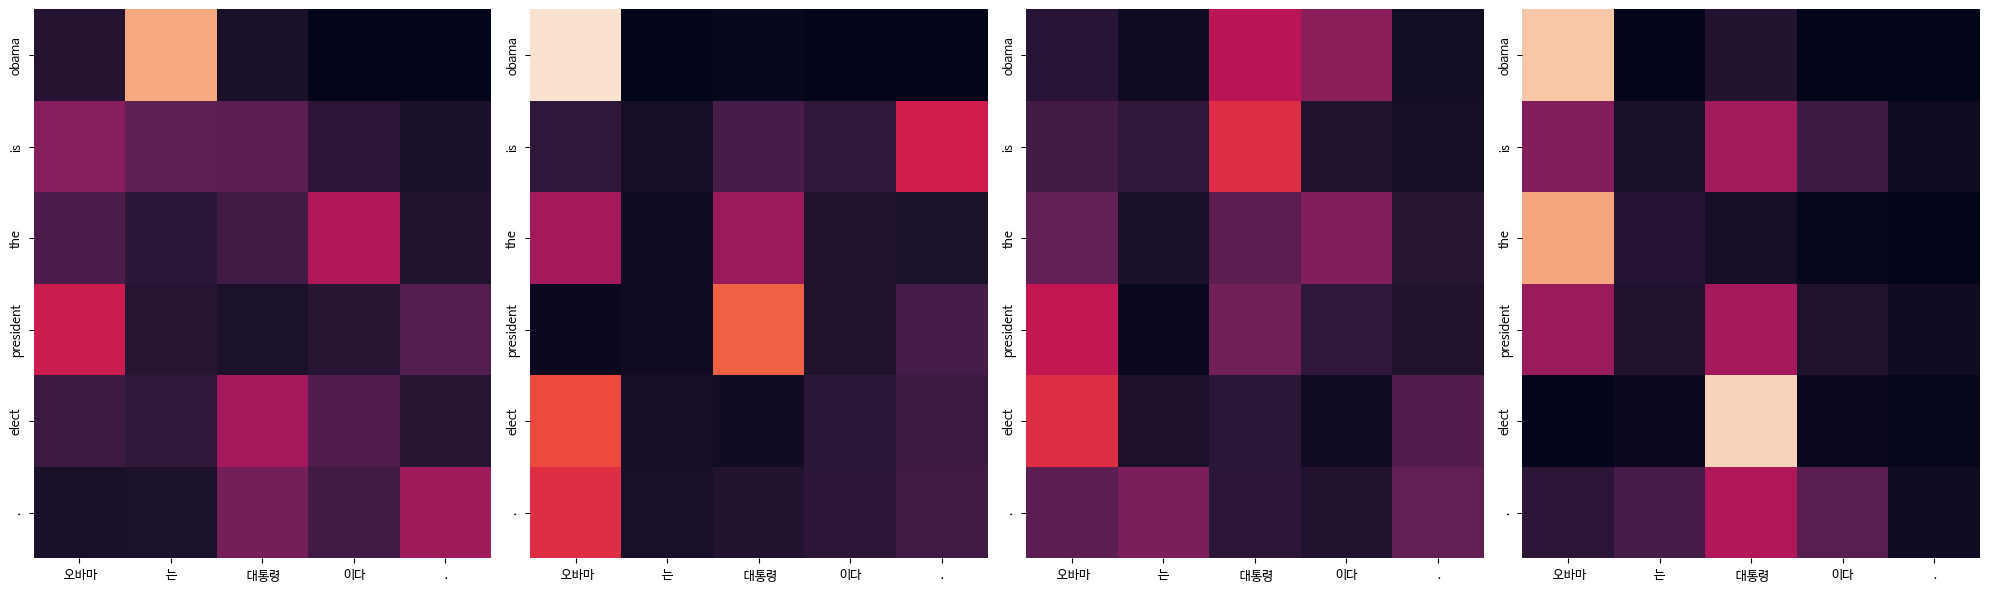

Decoder Self Layer 2


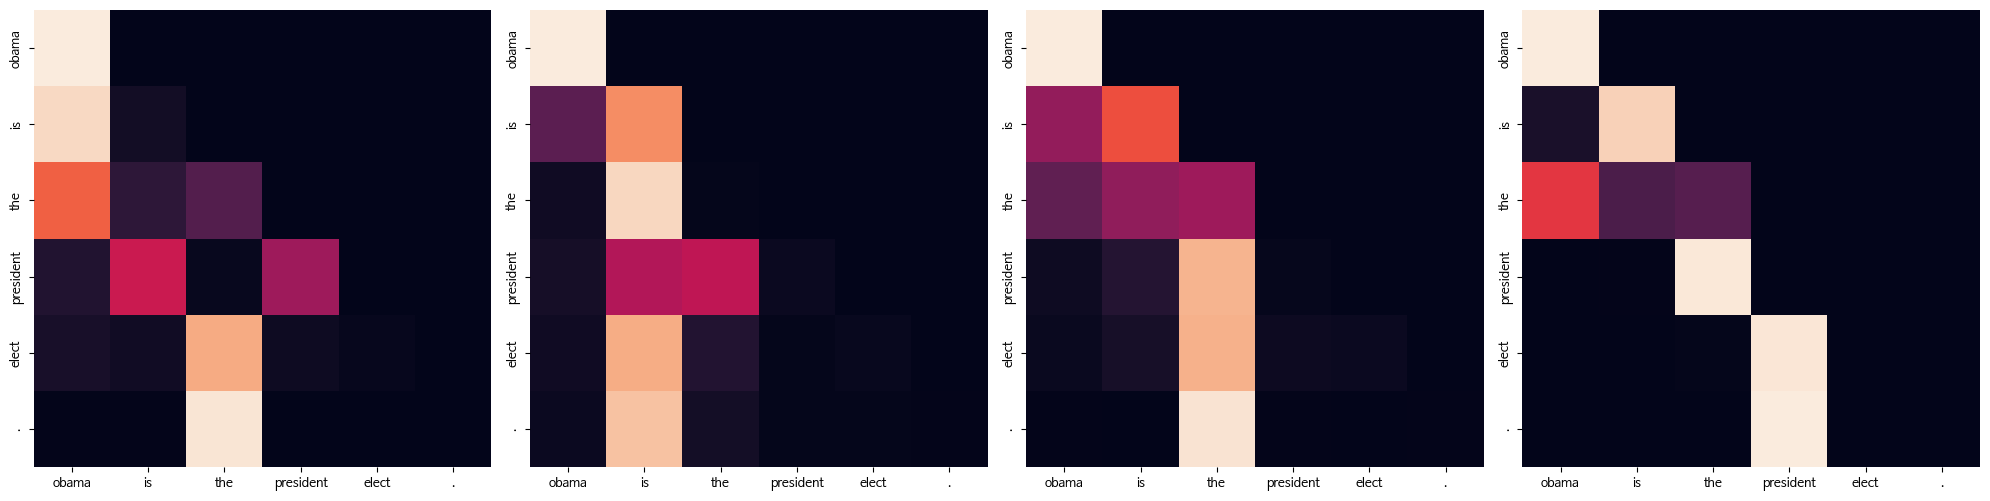

Decoder Src Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


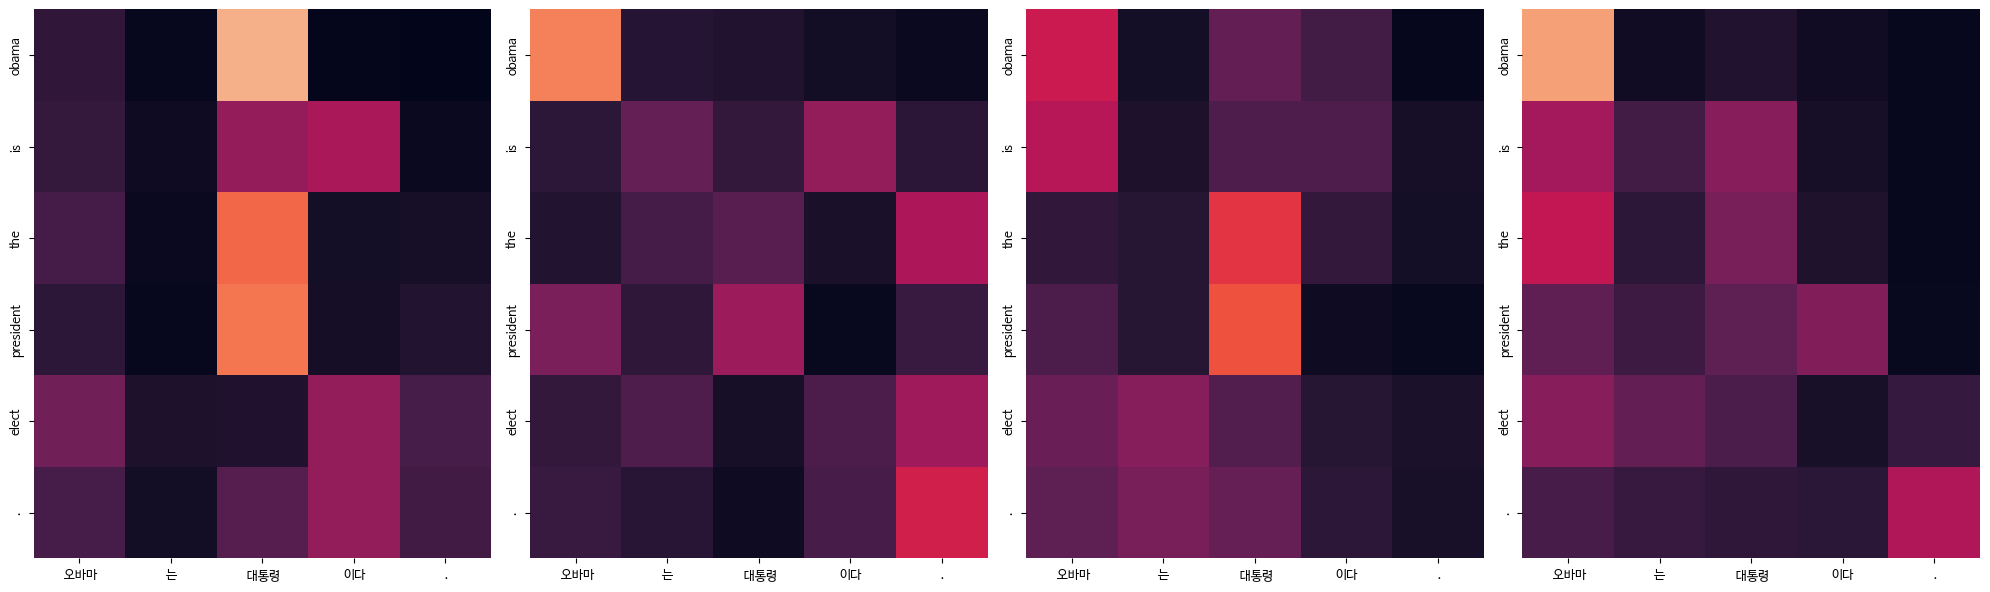

--------------------------------------------------
Input: 시민들은 도시 속에 산다.
Predicted: the city is one of the most popular cities .
Encoder Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


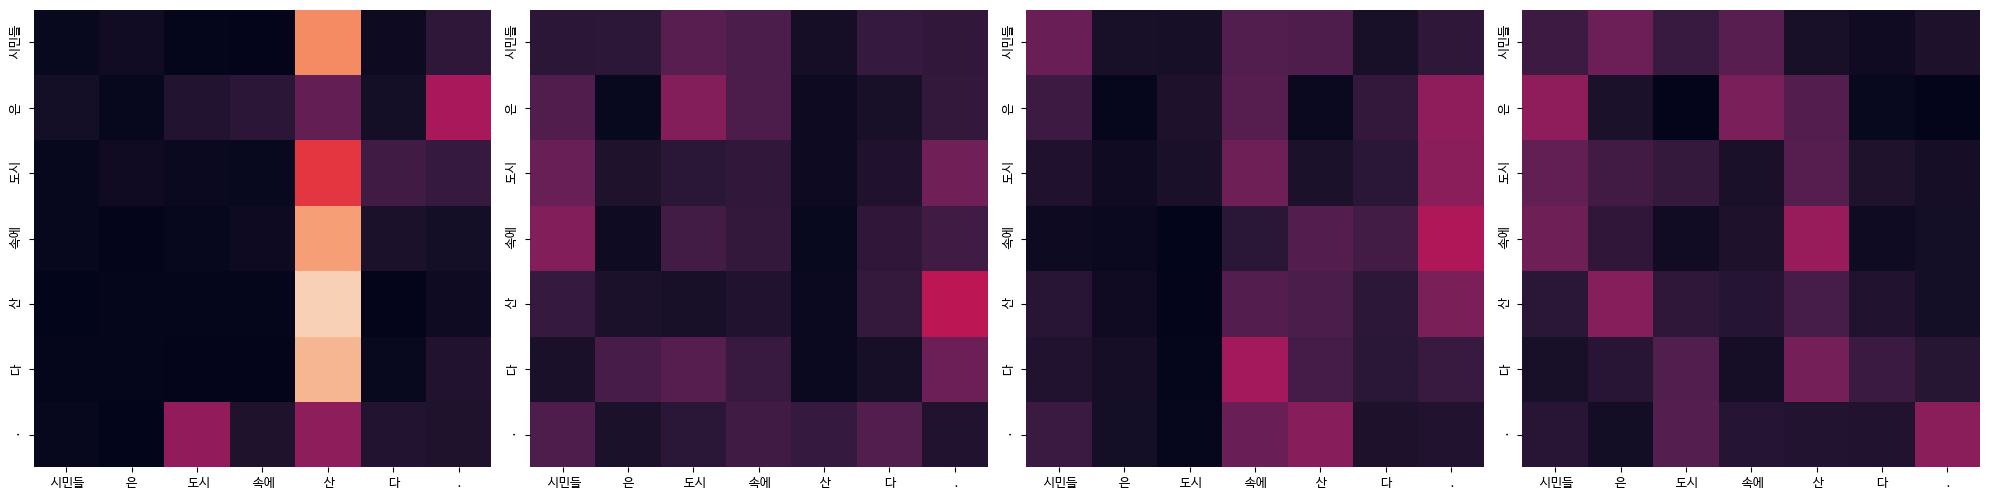

Encoder Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


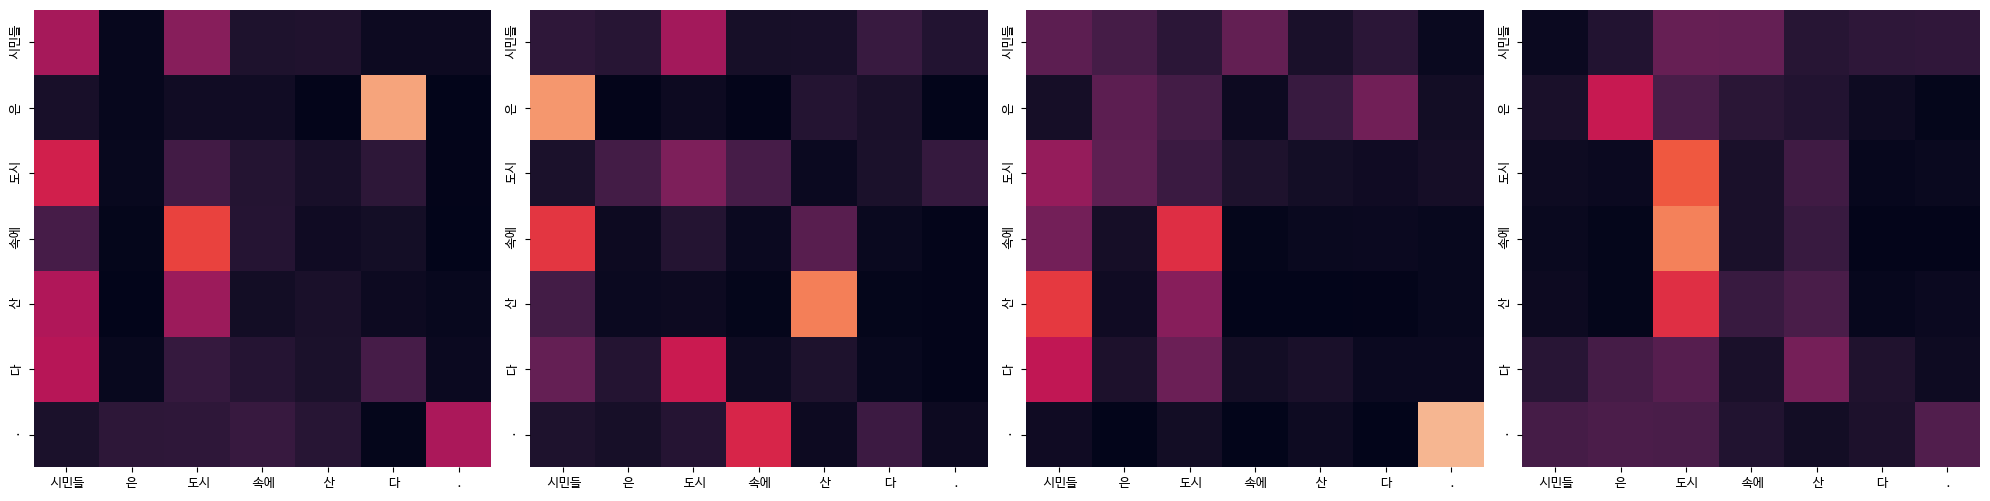

Decoder Self Layer 1


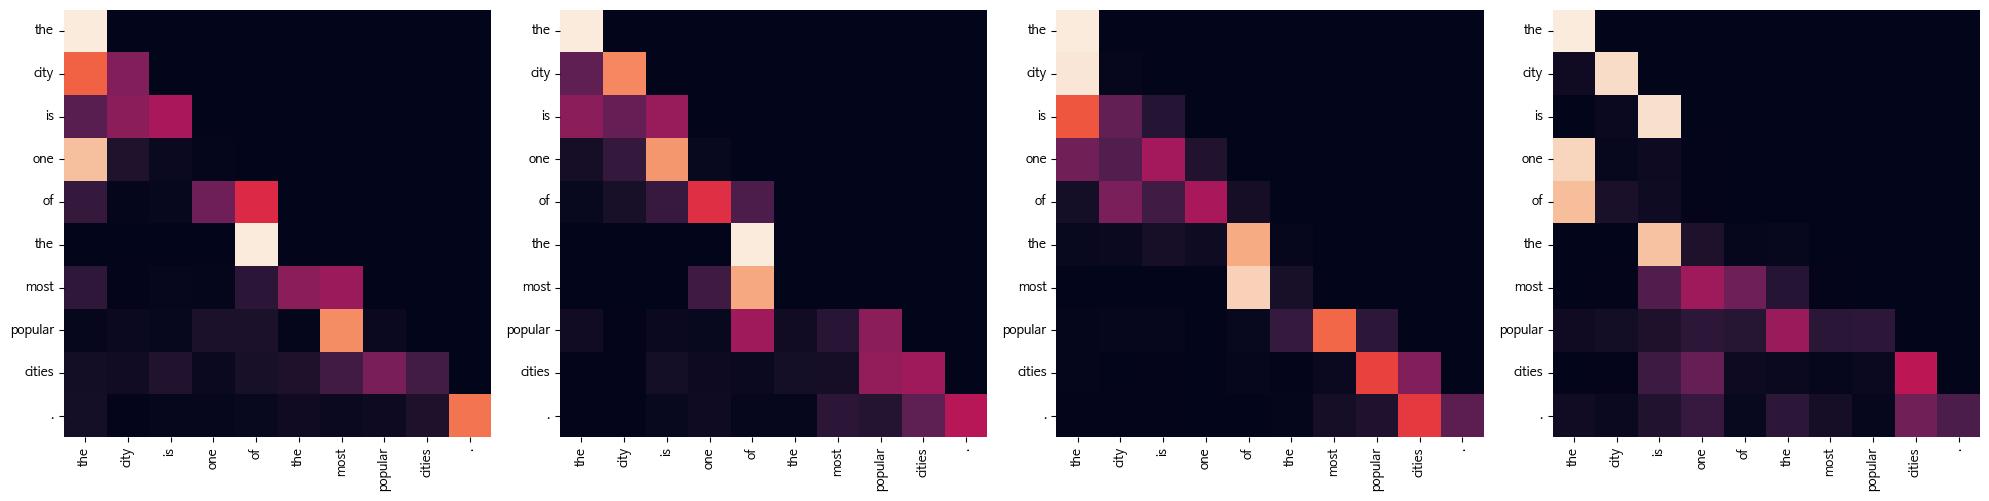

Decoder Src Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


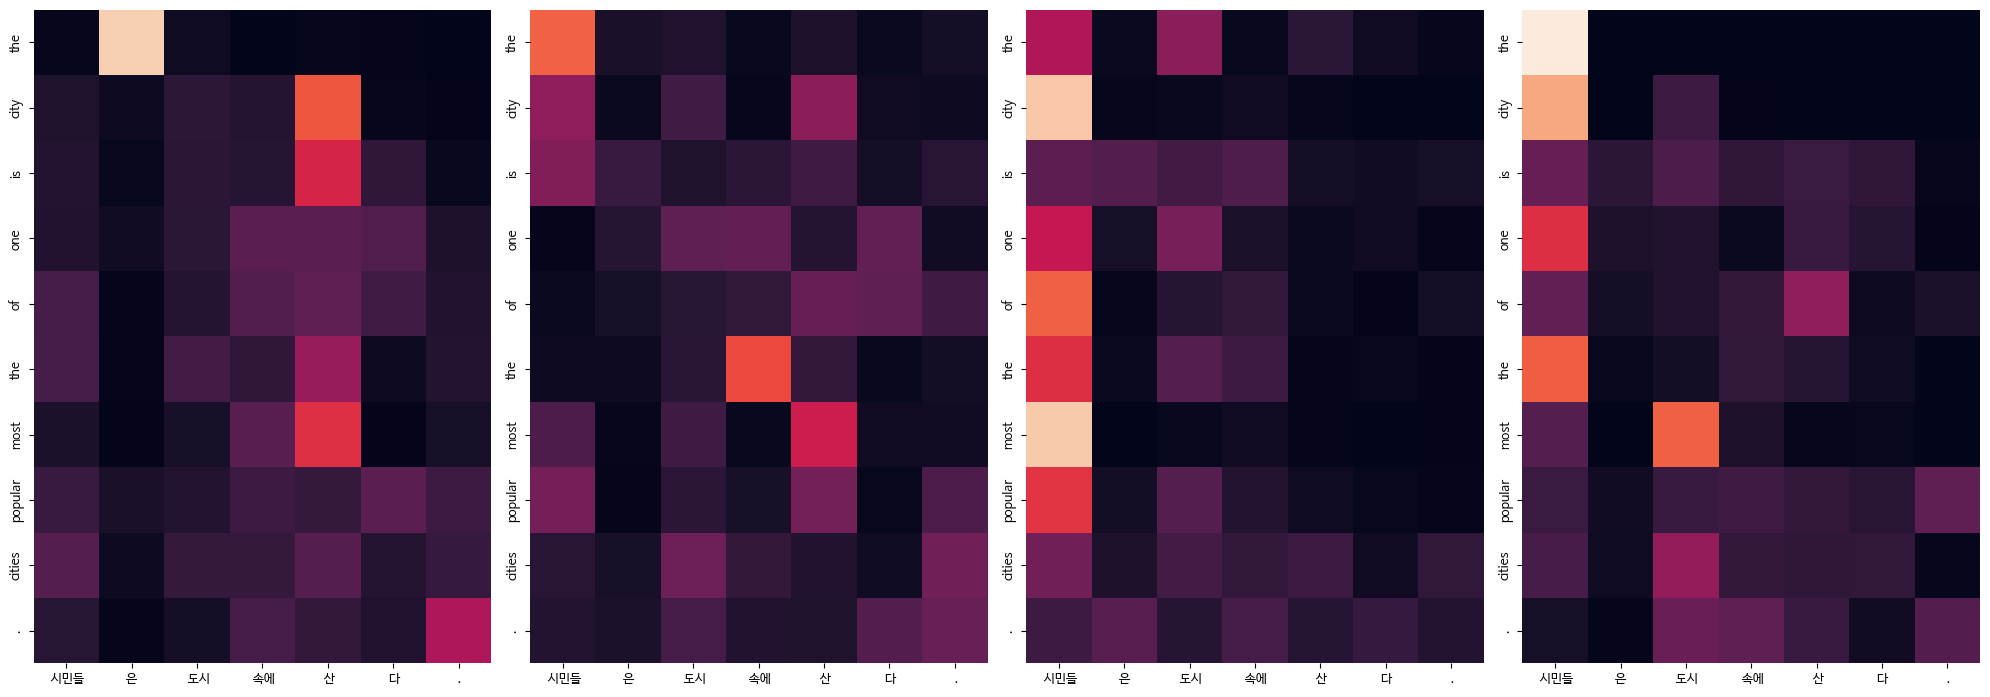

Decoder Self Layer 2


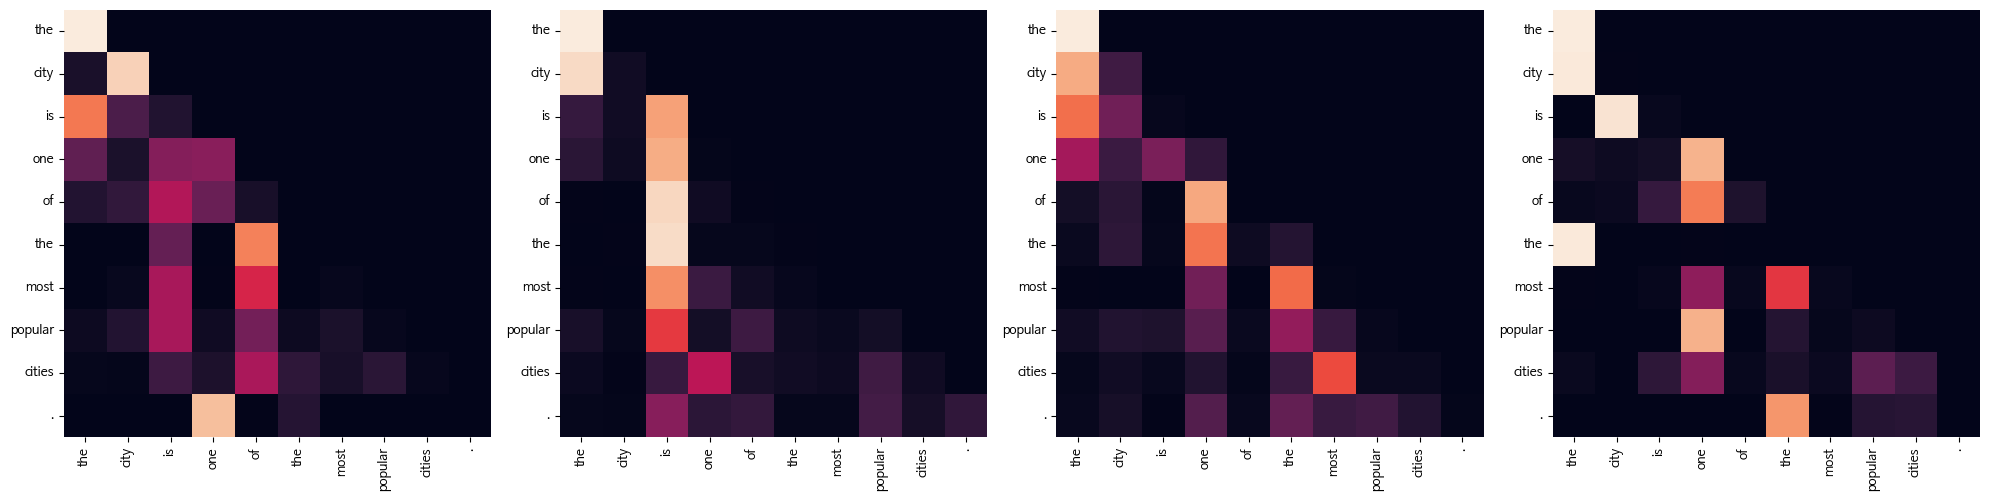

Decoder Src Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


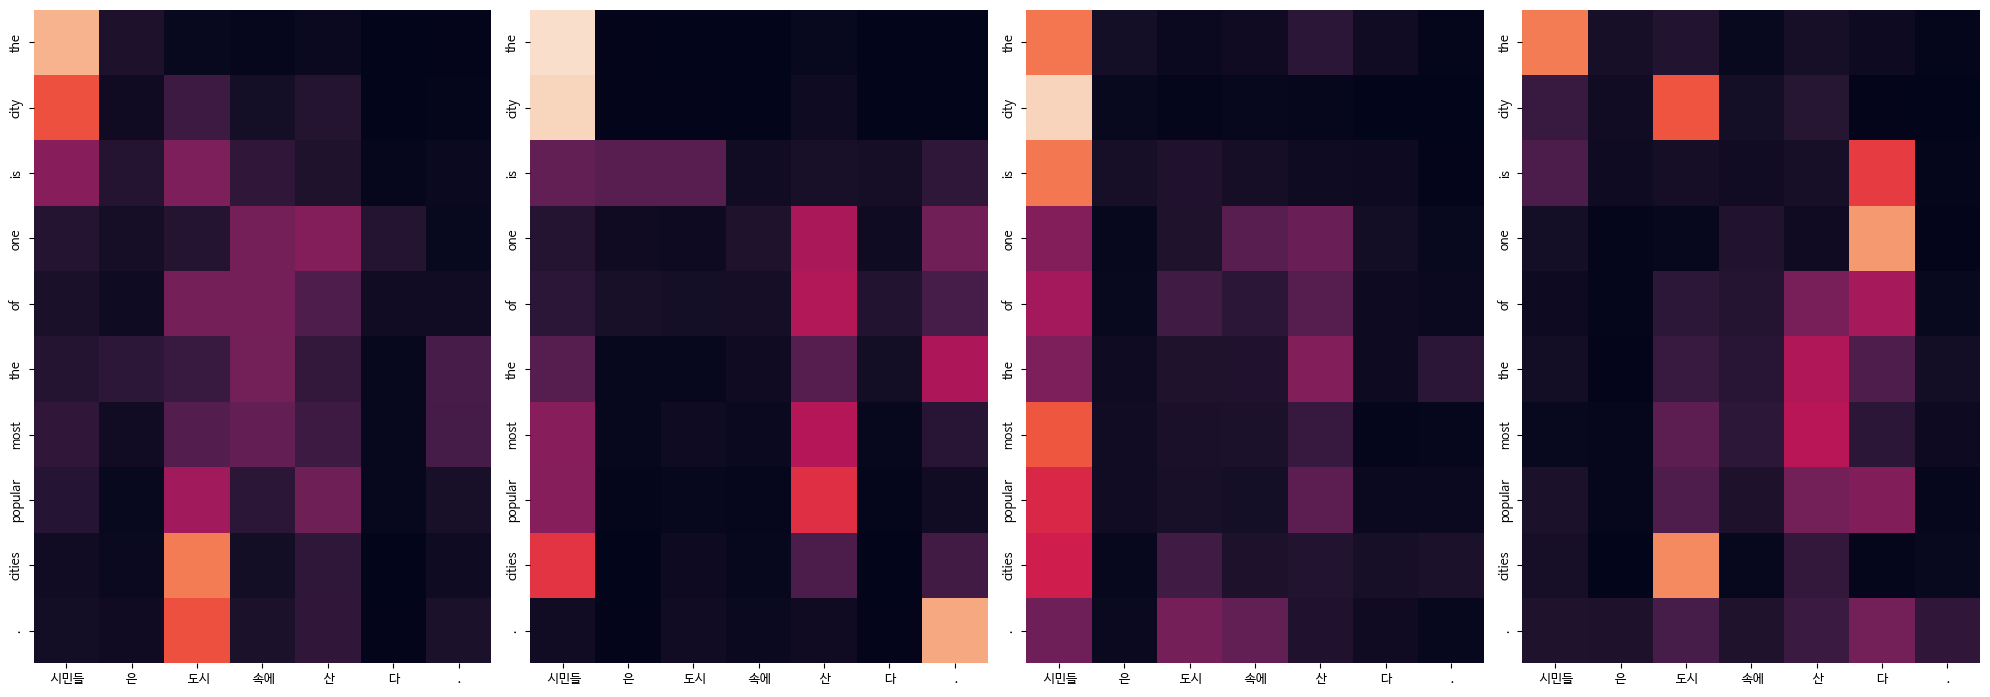

--------------------------------------------------
Input: 커피는 필요 없다.
Predicted: coffee is no coffee .
Encoder Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


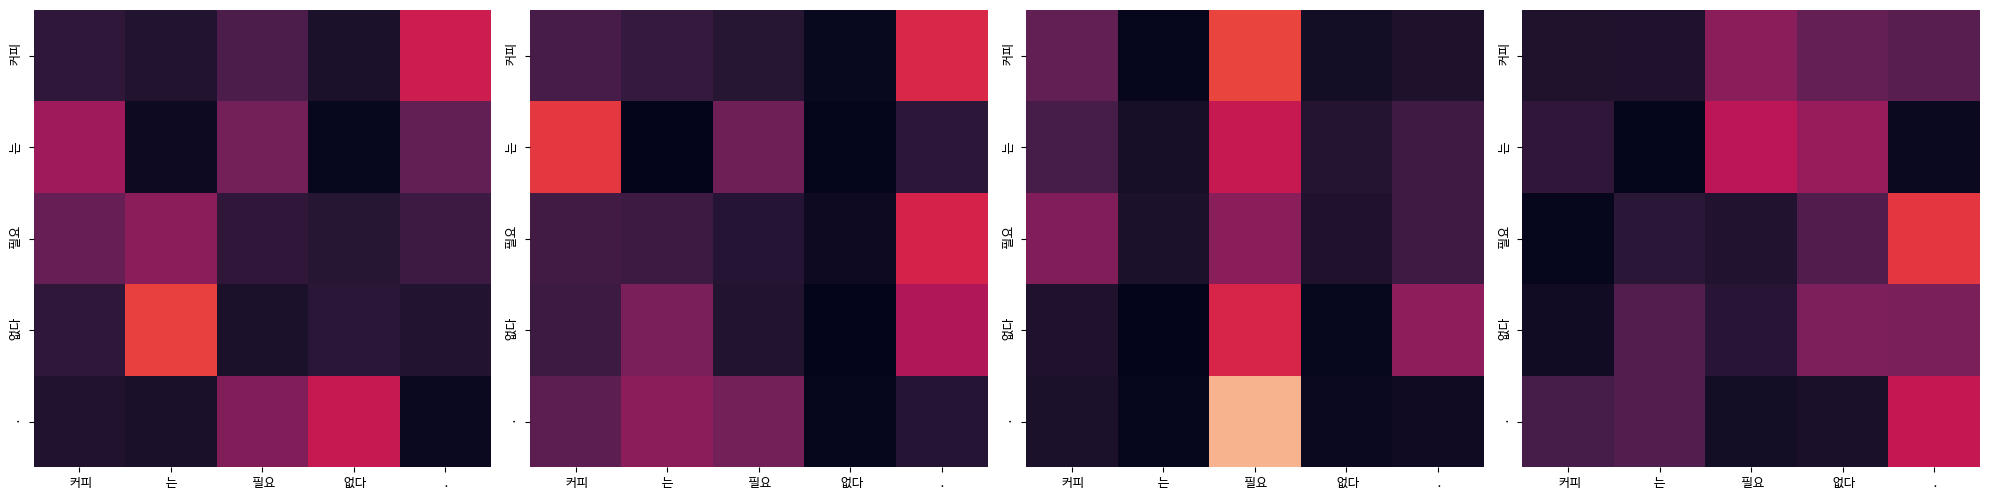

Encoder Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


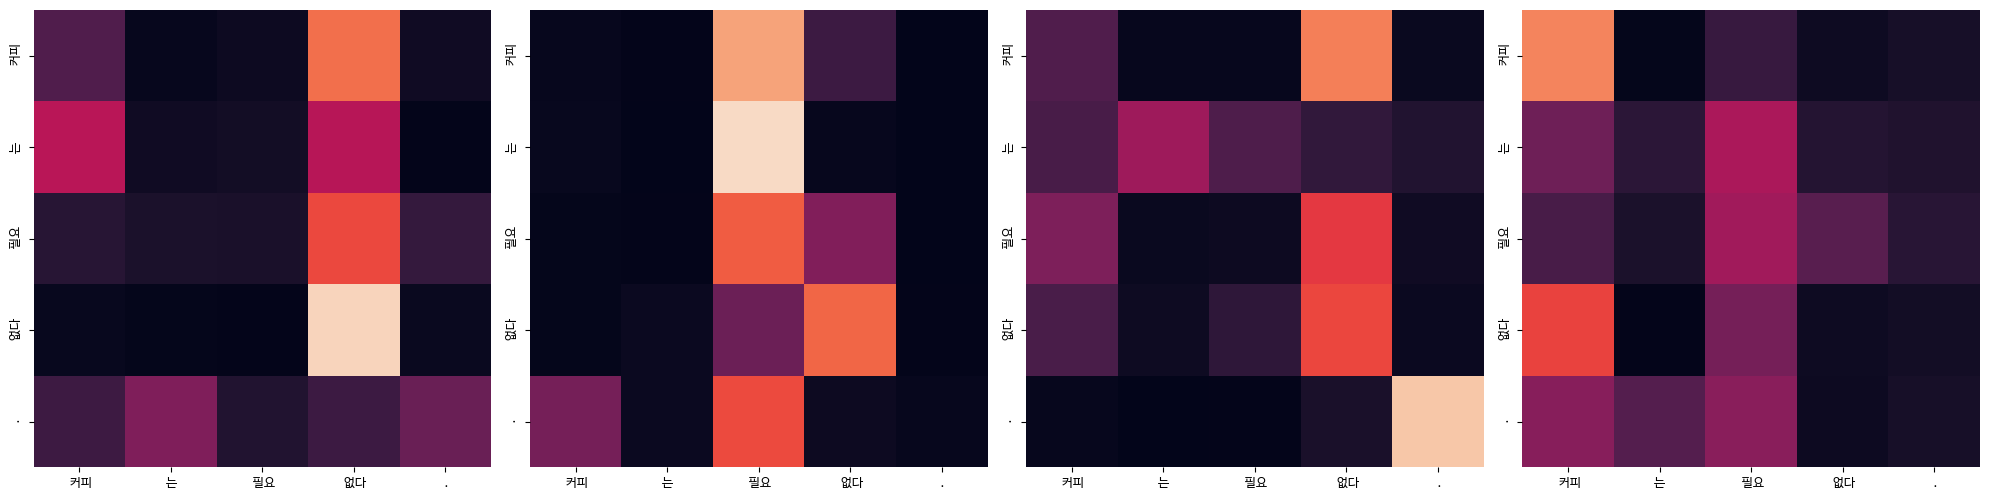

Decoder Self Layer 1


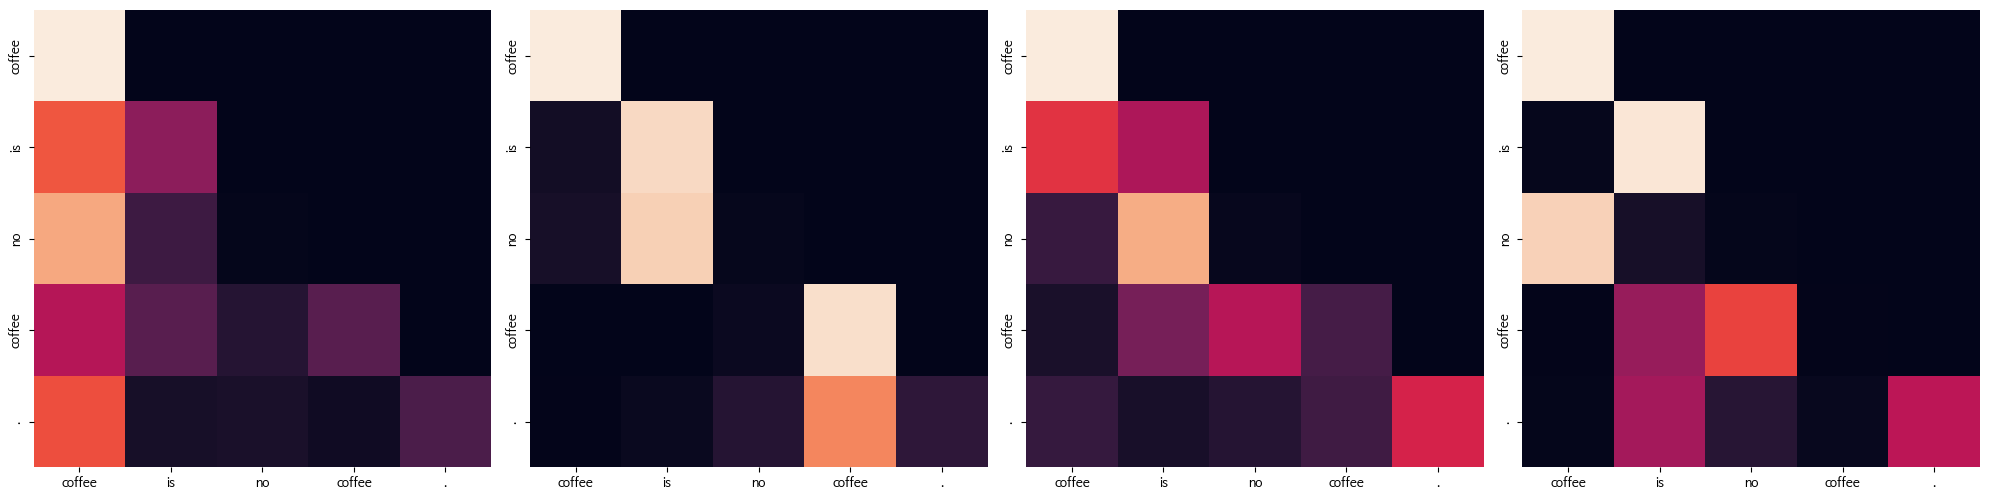

Decoder Src Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


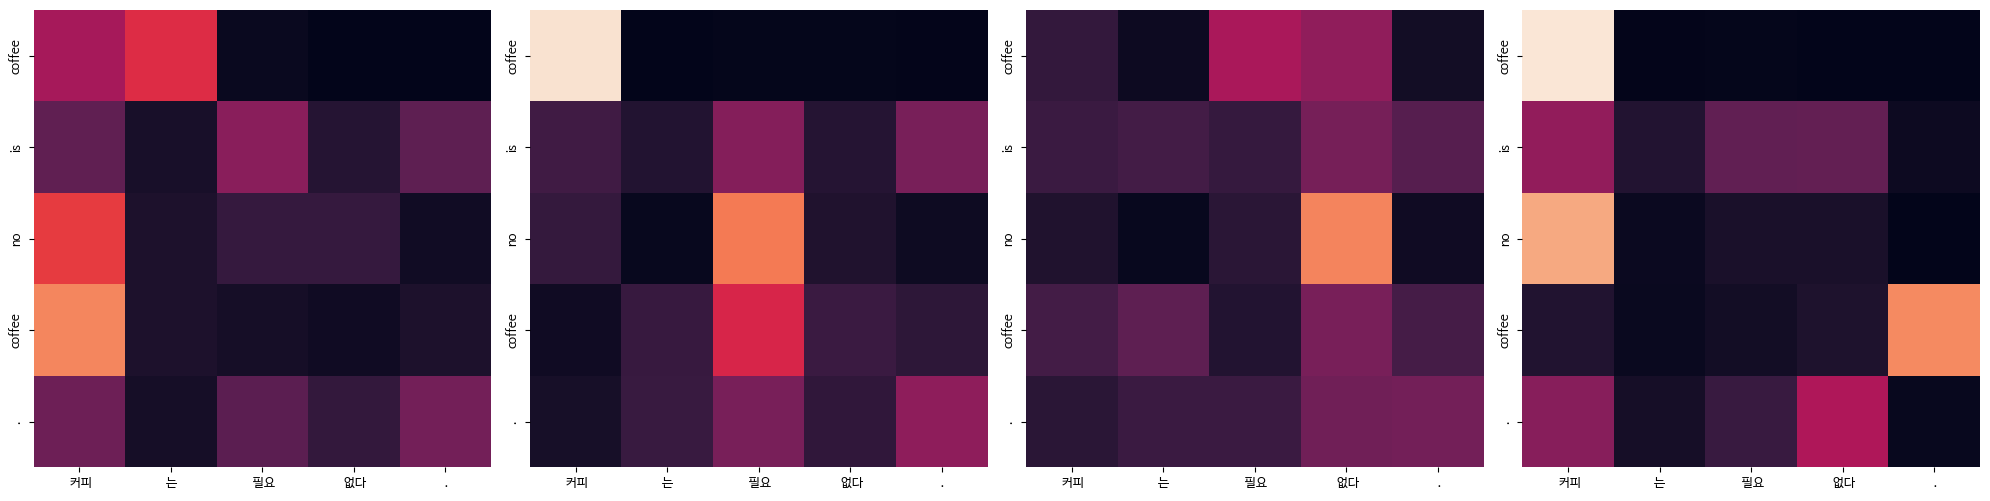

Decoder Self Layer 2


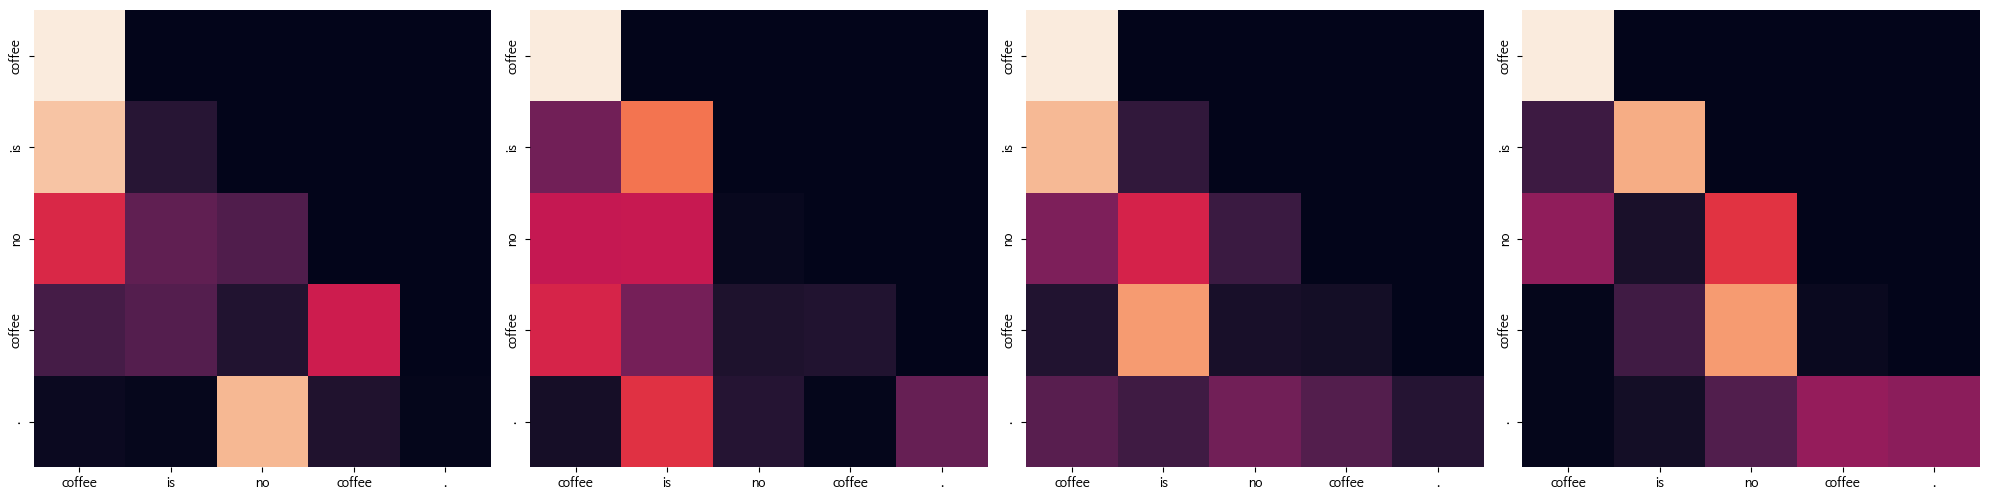

Decoder Src Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


In [ ]:
# 최종 번역 + Attention Map 시각화
print("=" * 50)
print("최종 번역 결과 + Attention Map")
print("=" * 50)

for ex in examples:
    translate(ex, transformer, ko_tokenizer, en_tokenizer, plot_attention=True)
    print("-" * 50)